# Evaluating the Impact of Image Augmentation Strategies on CNN Architectures in Skin Lesion Classification

**DS 6050, SP 2026 - ML III: Deep Learning Project** *For Professor Heman Shakeri, PhD, University of Virginia*

---

### Team Members
* **Robert Ashby** | *University of Virginia, School of Data Science* | Fernandina Beach, Florida | gsr3qz@virginia.edu
* **Xavier Colbert** | *University of Virginia, School of Data Science* | Alexandria, Virginia | kxp3jj@virginia.edu
* **Jacob Kuchta** | *University of Virginia, School of Data Science* | Arlington, Virginia | mjk3ku@virginia.edu
* **Alysa Pugmire** | *University of Virginia, School of Data Science* | Richmond, Virginia | amp3xs@virginia.edu

# 02 — Baseline Modeling

This notebook runs the first **image-only** baseline on the processed ISIC 2019 train/validation splits.

Default setup:
- pretrained `resnet50`
- resize to `224 x 224`
- ImageNet normalization
- weighted cross-entropy
- train on `DATA/processed/isic2019/train.csv`
- validate on `DATA/processed/isic2019/val.csv`

Later notebooks can reuse this structure for backbone comparison, augmentations, and ablations.

In [1]:
import sys, site
print("Python:", sys.executable)
print("User site:", site.getusersitepackages())

Python: /home/gsr3qz/.conda/envs/ds6050-skin/bin/python
User site: /home/gsr3qz/.local/lib/python3.11/site-packages


In [2]:
from pathlib import Path
import json
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.metrics import balanced_accuracy_score, roc_auc_score, confusion_matrix, classification_report

In [3]:
# Config
SEED = 42
BACKBONE = "resnet50"          # try: "resnet50", "efficientnet_b0", "densenet121"
IMAGE_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 5
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 0                # safer default on Windows notebooks
FREEZE_FEATURES = False
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Device:", DEVICE)

Device: cuda


In [4]:
# Paths
cwd = Path.cwd().resolve()
ROOT = cwd.parent if cwd.name.lower() == "code" else cwd
DATA = ROOT / "DATA"
PROCESSED = DATA / "processed"

train_csv = PROCESSED / "isic2019" / "train.csv"
val_csv = PROCESSED / "isic2019" / "val.csv"
weights_json = PROCESSED / "class_weights.json"

OUT_ROOT = ROOT / "outputs"
CKPT_DIR = OUT_ROOT / "checkpoints"
FIG_DIR = OUT_ROOT / "figures" / "02_baseline_modeling"
METRIC_DIR = OUT_ROOT / "metrics"
PRED_DIR = OUT_ROOT / "preds"

for d in [CKPT_DIR, FIG_DIR, METRIC_DIR, PRED_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(train_csv)
print(val_csv)
print(weights_json)

/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_ML_III_Deep_Learning_Project_Ashby_Colbert_Kuchta_Pugmire/DATA/processed/isic2019/train.csv
/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_ML_III_Deep_Learning_Project_Ashby_Colbert_Kuchta_Pugmire/DATA/processed/isic2019/val.csv
/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_ML_III_Deep_Learning_Project_Ashby_Colbert_Kuchta_Pugmire/DATA/processed/class_weights.json


In [5]:
train_df = pd.read_csv(train_csv)
val_df = pd.read_csv(val_csv)

with open(weights_json, "r") as f:
    class_weights_dict = json.load(f)

required_cols = ["image_path", "label"]
for col in required_cols:
    if col not in train_df.columns:
        raise ValueError(f"Missing required column: {col}")

labels = sorted(train_df["label"].unique())
label_to_idx = {label: idx for idx, label in enumerate(labels)}
idx_to_label = {idx: label for label, idx in label_to_idx.items()}

train_df["label_idx"] = train_df["label"].map(label_to_idx)
val_df["label_idx"] = val_df["label"].map(label_to_idx)

class_weight_tensor = torch.tensor(
    [class_weights_dict[label] for label in labels],
    dtype=torch.float32,
    device=DEVICE
)

print("Labels:", labels)
print("Train shape:", train_df.shape)
print("Val shape:  ", val_df.shape)
print("Class weights tensor:", class_weight_tensor)

Labels: ['AK', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'SCC', 'VASC']
Train shape: (21531, 22)
Val shape:   (3800, 22)
Class weights tensor: tensor([ 3.6518,  0.9530,  1.2069, 13.2580,  0.7001,  0.2459,  5.0400, 12.5180],
       device='cuda:0')


In [6]:
class ISICDataset(Dataset):
    def __init__(self, df, root, transform=None):
        self.df = df.reset_index(drop=True)
        self.root = root
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(self.root / row["image_path"]).convert("RGB")
        label = int(row["label_idx"])

        if self.transform is not None:
            image = self.transform(image)

        return image, label, row["image_path"]

def make_phase1_transforms(image_size=224):
    normalize = transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )

    train_tf = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        normalize,
    ])

    val_tf = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        normalize,
    ])

    return train_tf, val_tf

In [10]:
# Normalize path columns for cross-platform use BEFORE creating datasets/loaders
def normalize_path_column(df, col):
    df = df.copy()
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace("\\", "/", regex=False)
    return df

train_df = normalize_path_column(train_df, "image_path")
val_df   = normalize_path_column(val_df, "image_path")

print("Example normalized train paths:")
print(train_df["image_path"].head(3).tolist())

# Build transforms
train_tf, val_tf = make_phase1_transforms(IMAGE_SIZE)

# Build datasets
train_ds = ISICDataset(train_df, ROOT, transform=train_tf)
val_ds   = ISICDataset(val_df, ROOT, transform=val_tf)

# Build dataloaders
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

# Smoke test one batch
batch_images, batch_labels, batch_paths = next(iter(train_loader))
print("Batch image shape:", batch_images.shape)
print("Batch label shape:", batch_labels.shape)
print("Example paths:", batch_paths[:3])

Example normalized train paths:
['DATA/isic2019/train/images/ISIC_2019_Training_Input/ISIC_0029767.jpg', 'DATA/isic2019/train/images/ISIC_2019_Training_Input/ISIC_0071877.jpg', 'DATA/isic2019/train/images/ISIC_2019_Training_Input/ISIC_0028390.jpg']
Batch image shape: torch.Size([32, 3, 224, 224])
Batch label shape: torch.Size([32])
Example paths: ['DATA/isic2019/train/images/ISIC_2019_Training_Input/ISIC_0024932.jpg', 'DATA/isic2019/train/images/ISIC_2019_Training_Input/ISIC_0053975.jpg', 'DATA/isic2019/train/images/ISIC_2019_Training_Input/ISIC_0032343.jpg']


In [11]:
def build_model(backbone, num_classes, freeze_features=False):
    if backbone == "resnet50":
        model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        if freeze_features:
            for param in model.parameters():
                param.requires_grad = False
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)

    elif backbone == "efficientnet_b0":
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        if freeze_features:
            for param in model.parameters():
                param.requires_grad = False
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)

    elif backbone == "densenet121":
        model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
        if freeze_features:
            for param in model.parameters():
                param.requires_grad = False
        in_features = model.classifier.in_features
        model.classifier = nn.Linear(in_features, num_classes)

    else:
        raise ValueError(f"Unsupported backbone: {backbone}")

    return model

model = build_model(BACKBONE, num_classes=len(labels), freeze_features=FREEZE_FEATURES).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weight_tensor)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

print(model.__class__.__name__)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /home/gsr3qz/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 347MB/s]


ResNet


In [12]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    n_samples = 0

    for images, targets, _ in loader:
        images = images.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size
        n_samples += batch_size

    return running_loss / max(n_samples, 1)


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    n_samples = 0

    all_targets = []
    all_preds = []
    all_probs = []
    all_paths = []

    for images, targets, paths in loader:
        images = images.to(device)
        targets = targets.to(device)

        logits = model(images)
        loss = criterion(logits, targets)
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size
        n_samples += batch_size

        all_targets.extend(targets.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_paths.extend(paths)

    avg_loss = running_loss / max(n_samples, 1)
    y_true = np.array(all_targets)
    y_pred = np.array(all_preds)
    y_prob = np.array(all_probs)

    bal_acc = balanced_accuracy_score(y_true, y_pred)

    try:
        macro_auc = roc_auc_score(y_true, y_prob, multi_class="ovr", average="macro")
    except ValueError:
        macro_auc = np.nan

    return {
        "loss": avg_loss,
        "balanced_accuracy": bal_acc,
        "macro_auc": macro_auc,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "paths": all_paths,
    }

In [13]:
history = {
    "epoch": [],
    "train_loss": [],
    "val_loss": [],
    "val_balanced_accuracy": [],
    "val_macro_auc": [],
}

best_score = -np.inf
best_ckpt_path = CKPT_DIR / f"{BACKBONE}_phase1_best.pt"

start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_metrics = evaluate(model, val_loader, criterion, DEVICE)

    current_score = val_metrics["macro_auc"]
    if np.isnan(current_score):
        current_score = val_metrics["balanced_accuracy"]

    if current_score > best_score:
        best_score = current_score
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "label_to_idx": label_to_idx,
                "backbone": BACKBONE,
                "image_size": IMAGE_SIZE,
            },
            best_ckpt_path
        )

    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_metrics["loss"])
    history["val_balanced_accuracy"].append(val_metrics["balanced_accuracy"])
    history["val_macro_auc"].append(val_metrics["macro_auc"])

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_bal_acc={val_metrics['balanced_accuracy']:.4f} | "
        f"val_macro_auc={val_metrics['macro_auc']:.4f}"
    )

elapsed = time.time() - start_time
print(f"Training finished in {elapsed/60:.2f} minutes")
print(f"Best checkpoint: {best_ckpt_path}")

Epoch 01 | train_loss=1.2978 | val_loss=1.0095 | val_bal_acc=0.6249 | val_macro_auc=0.9260
Epoch 02 | train_loss=0.7635 | val_loss=0.8614 | val_bal_acc=0.7119 | val_macro_auc=0.9457
Epoch 03 | train_loss=0.5204 | val_loss=0.8279 | val_bal_acc=0.7188 | val_macro_auc=0.9580
Epoch 04 | train_loss=0.3274 | val_loss=0.9040 | val_bal_acc=0.7282 | val_macro_auc=0.9565
Epoch 05 | train_loss=0.2328 | val_loss=0.9632 | val_bal_acc=0.7326 | val_macro_auc=0.9568
Training finished in 34.23 minutes
Best checkpoint: /sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_ML_III_Deep_Learning_Project_Ashby_Colbert_Kuchta_Pugmire/outputs/checkpoints/resnet50_phase1_best.pt


,epoch,train_loss,val_loss,val_balanced_accuracy,val_macro_auc
0,1,1.297785,1.009524,0.624941,0.925953
1,2,0.763470,0.861431,0.711920,0.945748
2,3,0.520388,0.827873,0.718830,0.958045
3,4,0.327443,0.904040,0.728208,0.956516
4,5,0.232776,0.963165,0.732603,0.956780


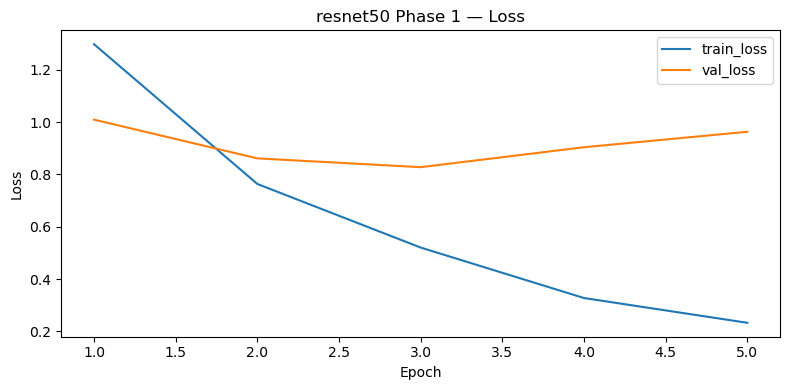

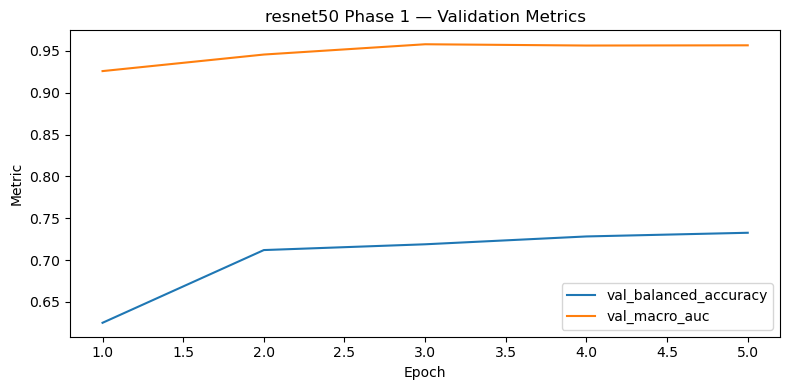

In [15]:
history_df = pd.DataFrame(history)
display(history_df)
history_df.to_csv(METRIC_DIR / f"{BACKBONE}_phase1_history.csv", index=False)

plt.figure(figsize=(8, 4))
plt.plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"{BACKBONE} Phase 1 — Loss")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / f"{BACKBONE}_phase1_loss_curve.png", dpi=200, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history_df["epoch"], history_df["val_balanced_accuracy"], label="val_balanced_accuracy")
plt.plot(history_df["epoch"], history_df["val_macro_auc"], label="val_macro_auc")
plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.title(f"{BACKBONE} Phase 1 — Validation Metrics")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / f"{BACKBONE}_phase1_metric_curve.png", dpi=200, bbox_inches="tight")
plt.show()

In [16]:
# Load best checkpoint and evaluate once more
checkpoint = torch.load(best_ckpt_path, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])

val_metrics = evaluate(model, val_loader, criterion, DEVICE)
y_true = val_metrics["y_true"]
y_pred = val_metrics["y_pred"]
y_prob = val_metrics["y_prob"]

print("Final validation balanced accuracy:", round(val_metrics["balanced_accuracy"], 4))
print("Final validation macro AUC:", round(val_metrics["macro_auc"], 4))

/tmp/ipykernel_234866/3469828456.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(best_ckpt_path, map_location=DEVICE)


Final validation balanced accuracy: 0.7188
Final validation macro AUC: 0.958


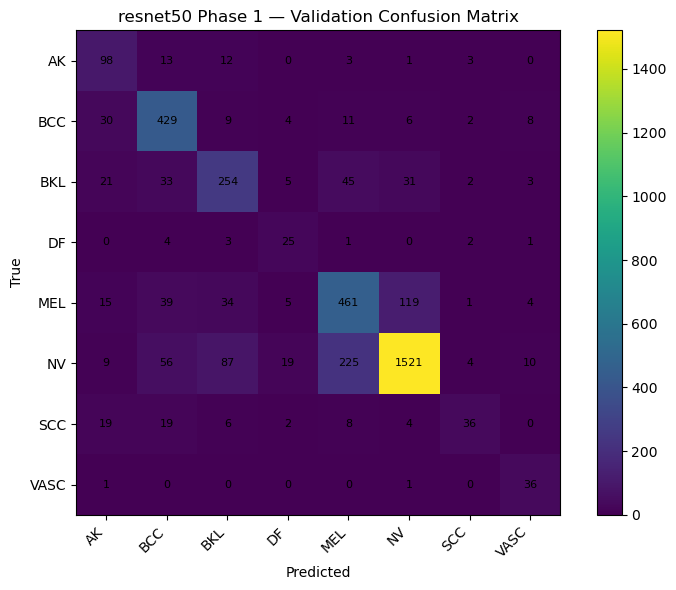

,precision,recall,f1-score,support
AK,0.507772,0.753846,0.606811,130.000000
BCC,0.723440,0.859719,0.785714,499.000000
BKL,0.627160,0.644670,0.635795,394.000000
DF,0.416667,0.694444,0.520833,36.000000
MEL,0.611406,0.679941,0.643855,678.000000
NV,0.903743,0.787675,0.841727,1931.000000
SCC,0.720000,0.382979,0.500000,94.000000
VASC,0.580645,0.947368,0.720000,38.000000
accuracy,0.752632,0.752632,0.752632,0.752632
macro avg,0.636354,0.718830,0.656842,3800.000000


In [17]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(labels)))

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm)
ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticklabels(labels)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"{BACKBONE} Phase 1 — Validation Confusion Matrix")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=8)

fig.colorbar(im)
plt.tight_layout()
plt.savefig(FIG_DIR / f"{BACKBONE}_phase1_confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()

report = classification_report(
    y_true,
    y_pred,
    target_names=labels,
    output_dict=True,
    zero_division=0
)
report_df = pd.DataFrame(report).T
display(report_df)
report_df.to_csv(METRIC_DIR / f"{BACKBONE}_phase1_classification_report.csv")

In [18]:
# Save validation predictions
pred_df = pd.DataFrame({
    "image_path": val_metrics["paths"],
    "true_idx": y_true,
    "pred_idx": y_pred,
    "true_label": [idx_to_label[i] for i in y_true],
    "pred_label": [idx_to_label[i] for i in y_pred],
    "max_prob": y_prob.max(axis=1),
})

for i, label in enumerate(labels):
    pred_df[f"prob_{label}"] = y_prob[:, i]

pred_out = PRED_DIR / f"{BACKBONE}_phase1_val_predictions.csv"
pred_df.to_csv(pred_out, index=False)
print(f"Saved predictions: {pred_out}")
display(pred_df.head())

Saved predictions: /sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_ML_III_Deep_Learning_Project_Ashby_Colbert_Kuchta_Pugmire/outputs/preds/resnet50_phase1_val_predictions.csv


,image_path,true_idx,pred_idx,true_label,pred_label,max_prob,prob_AK,prob_BCC,prob_BKL,prob_DF,prob_MEL,prob_NV,prob_SCC,prob_VASC
0,DATA/isic2019/train/images/ISIC_2019_Training_...,5,5,NV,NV,0.904463,0.000287,0.000054,0.000752,0.000207,0.093790,0.904463,0.000420,0.000026
1,DATA/isic2019/train/images/ISIC_2019_Training_...,5,5,NV,NV,0.969743,0.000061,0.000074,0.001128,0.000807,0.027865,0.969743,0.000235,0.000087
2,DATA/isic2019/train/images/ISIC_2019_Training_...,5,4,NV,MEL,0.591335,0.000940,0.019736,0.095510,0.003739,0.591335,0.278801,0.003081,0.006857
3,DATA/isic2019/train/images/ISIC_2019_Training_...,4,4,MEL,MEL,0.492275,0.007993,0.444556,0.010463,0.003191,0.492275,0.033156,0.008007,0.000360
4,DATA/isic2019/train/images/ISIC_2019_Training_...,2,2,BKL,BKL,0.926758,0.000293,0.000371,0.926758,0.000225,0.014012,0.057526,0.000104,0.000711


## Next moves

After this notebook runs cleanly, you can:

1. copy it to `03_backbone_comparison.ipynb` and change `BACKBONE`,
2. add augmentation phases in `04_augmentation_experiments.ipynb`,
3. reuse the saved validation predictions for error analysis in the checkpoint report.